In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
#1. Load the Dataset

import pandas as pd

# Load the dataset
data = pd.read_csv(r"C:\Users\hsami\Downloads\EDA DATASET-3.zip")

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumn names:")
print(data.columns.tolist())

Dataset loaded successfully!

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset shape:
(1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [4]:
# 2.Check the data

print("\nData types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

print("\nStatistical summary:")
print(data.describe())


Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows:
723

Statistical summary:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000  

In [6]:
#3. Clean the data

# Remove duplicate rows
data = data.drop_duplicates()

print("\nShape after removing duplicates:")
print(data.shape)

# Convert columns to numeric
numeric_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

for column in numeric_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce"
    )

# Check missing values again
print("\nMissing values after cleaning:")
print(data.isnull().sum())


Shape after removing duplicates:
(302, 14)

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
# BASIC LEVEL QUESTIONS

#1. Average age

average_age = data["age"].mean()

print("\nAverage age:")
print(round(average_age, 2))


Average age:
54.42


In [10]:
#2. Gender Distribution

gender_distribution = data["sex"].value_counts()

print("\nGender distribution:")
print(gender_distribution)

gender_distribution.index = gender_distribution.index.map({
    0: "Female",
    1: "Male"
})

print("\nGender distribution:")
print(gender_distribution)


Gender distribution:
sex
1    206
0     96
Name: count, dtype: int64

Gender distribution:
sex
Male      206
Female     96
Name: count, dtype: int64


In [11]:
#3. Average blood pressure

average_bp = data["trestbps"].mean()

print("\nAverage resting blood pressure:")
print(round(average_bp, 2))


Average resting blood pressure:
131.6


In [12]:
#4.Fating Blood Sugar

high_fbs = data["fbs"].sum()

print("\nPatients with fasting blood sugar > 120:")
print(high_fbs)


Patients with fasting blood sugar > 120:
45


In [13]:
#5. Chest Pain Types

chest_pain_types = data["cp"].unique()

print("\nChest pain types:")
print(chest_pain_types)


Chest pain types:
[0 1 2 3]


In [14]:
#6. Maximum heart rate

maximum_heart_rate = data["thalach"].max()

print("\nMaximum heart rate:")
print(maximum_heart_rate)


Maximum heart rate:
202


In [15]:
#7. Exercise Angina Percentage

exercise_angina_percentage = data["exang"].mean() * 100

print("\nPercentage with exercise-induced angina:")
print(round(exercise_angina_percentage, 2), "%")




Percentage with exercise-induced angina:
32.78 %


In [16]:
#8.Average Cholesterol

average_cholesterol = data["chol"].mean()

print("\nAverage cholesterol:")
print(round(average_cholesterol, 2))


Average cholesterol:
246.5


In [17]:
#9. ECG

restecg_2 = (data["restecg"] == 2).sum()

print("\nPatients with resting ECG result 2:")
print(restecg_2)


Patients with resting ECG result 2:
4


In [18]:
#10. Major Vessels

major_vessels = data["ca"].value_counts()

print("\nMajor vessel distribution:")
print(major_vessels)


Major vessel distribution:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64


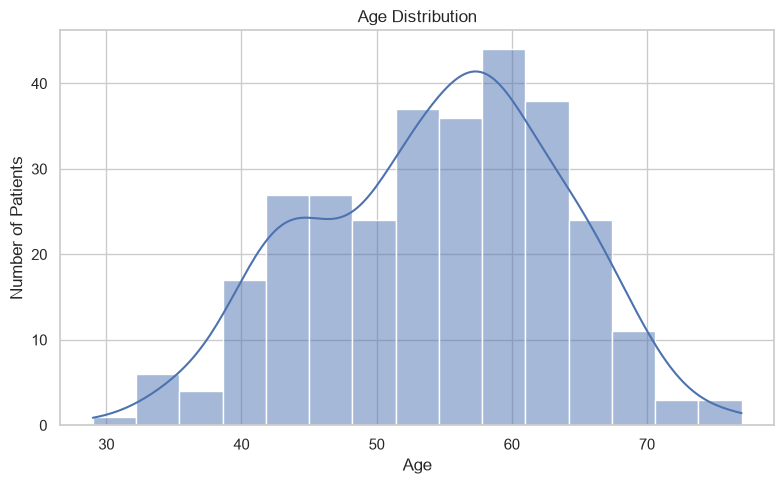

In [19]:
#1. Age Distribution 

plt.figure(figsize=(8, 5))

sns.histplot(
    data["age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

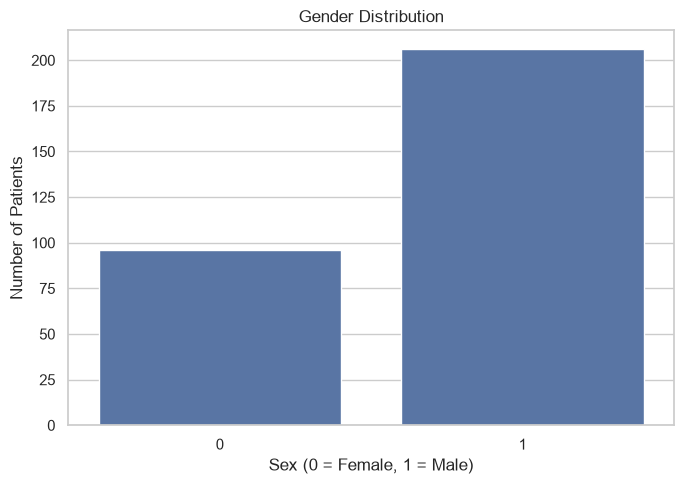

In [20]:
#2.Gender Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="sex"
)

plt.title("Gender Distribution")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

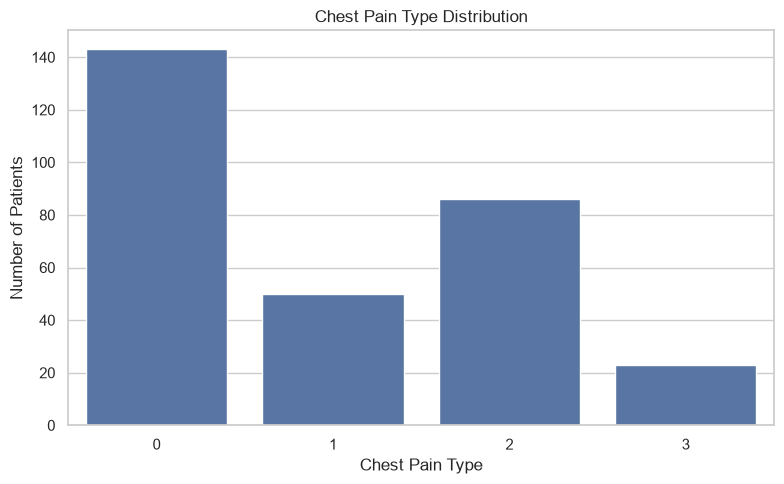

In [21]:
#3.Chest pain distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="cp"
)

plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

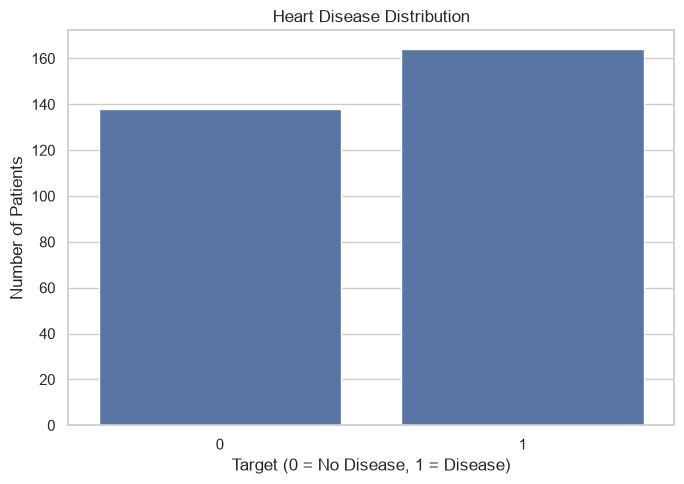

In [22]:
#4.Heart disease distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="target"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [23]:
# Medium Level Analysis

#1. Age vs cholesterol

correlation = data[["age", "chol"]].corr()

print("\nCorrelation between age and cholesterol:")
print(correlation)


Correlation between age and cholesterol:
           age      chol
age   1.000000  0.207216
chol  0.207216  1.000000



Chest pain by age group:
cp          0   1   2  3
age_group               
<40         4   3   6  2
40-49      28  19  22  3
50-59      61  21  34  9
60-69      46   4  21  9
70+         4   3   3  0


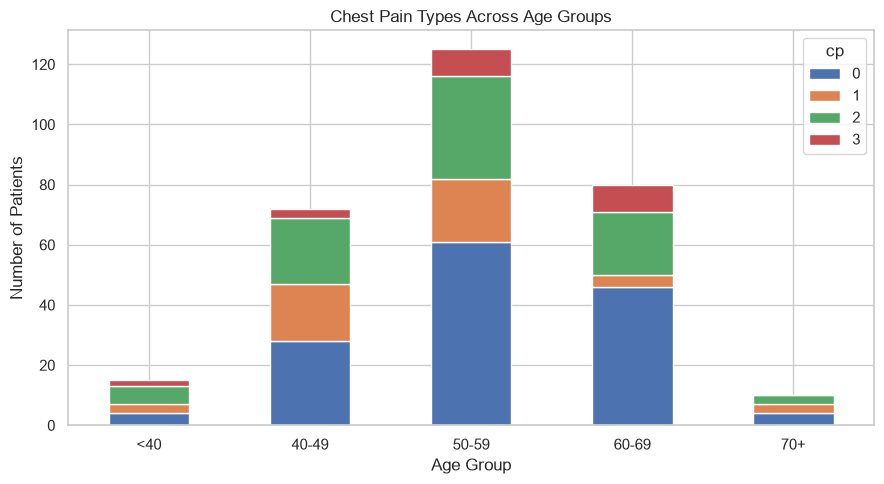

In [25]:
#2. Chest pain across age groups

data["age_group"] = pd.cut(
    data["age"],
    bins=[0, 39, 49, 59, 69, 100],
    labels=[
        "<40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

age_chest_pain = pd.crosstab(
    data["age_group"],
    data["cp"]
)

print("\nChest pain by age group:")
print(age_chest_pain)

age_chest_pain.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Chest Pain Types Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [26]:
#3. Heart rate vs exercise-induced angina

heart_rate_exang = data.groupby(
    "exang"
)["thalach"].mean()

print("\nAverage heart rate by exercise-induced angina:")
print(heart_rate_exang)


Average heart rate by exercise-induced angina:
exang
0    155.596059
1    137.212121
Name: thalach, dtype: float64


In [28]:
#4. Blood pressure by gender

bp_gender = data.groupby(
    "sex"
)["trestbps"].mean()

print("\nAverage blood pressure by gender:")
print(bp_gender)

male_bp = data[data["sex"] == 1]["trestbps"]

female_bp = data[data["sex"] == 0]["trestbps"]

t_stat, p_value = ttest_ind(
    male_bp,
    female_bp,
    equal_var=False
)

print("\nT-test result:")
print("T-statistic:", t_stat)
print("P-value:", p_value)


Average blood pressure by gender:
sex
0    133.083333
1    130.912621
Name: trestbps, dtype: float64

T-test result:
T-statistic: -0.9485481485051094
P-value: 0.3442505254559865



Fasting blood sugar vs heart disease:
target    0    1
fbs             
0       116  141
1        22   23


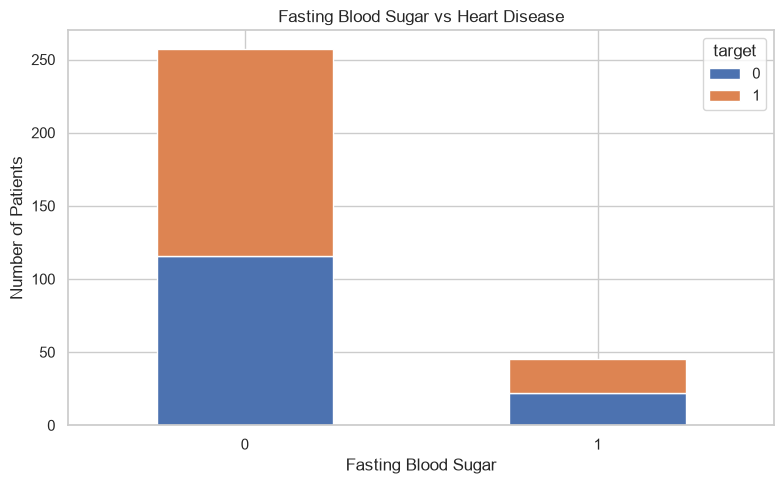

In [29]:
# 5. Fasting blood sugar vs heart disease

fbs_target = pd.crosstab(
    data["fbs"],
    data["target"]
)

print("\nFasting blood sugar vs heart disease:")
print(fbs_target)



fbs_target.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
#6. Major vessels vs heart disease

ca_target = pd.crosstab(
    data["ca"],
    data["target"]
)

print("\nMajor vessels vs heart disease:")
print(ca_target)


Major vessels vs heart disease:
target   0    1
ca             
0       45  130
1       44   21
2       31    7
3       17    3
4        1    3


In [31]:
# 7. Oldpeak by chest pain

oldpeak_cp = data.groupby(
    "cp"
)["oldpeak"].mean()

print("\nAverage oldpeak by chest pain:")
print(oldpeak_cp)


Average oldpeak by chest pain:
cp
0    1.383217
1    0.316000
2    0.806977
3    1.391304
Name: oldpeak, dtype: float64


In [32]:
# 8. Thalassemia vs heart disease

thal_target = pd.crosstab(
    data["thal"],
    data["target"]
)

print("\nThalassemia vs heart disease:")
print(thal_target)


Thalassemia vs heart disease:
target   0    1
thal           
0        1    1
1       12    6
2       36  129
3       89   28


In [33]:
# 9. Common risk-factor combinations

risk_combinations = (
    data[data["target"] == 1]
    .groupby(
        ["cp", "fbs", "exang", "thal"]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print("\nCommon risk-factor combinations:")
print(risk_combinations.head(10))


Common risk-factor combinations:
    cp  fbs  exang  thal  count
15   2    0      0     2     41
8    1    0      0     2     30
1    0    0      0     2     23
19   2    1      0     2     10
4    0    0      1     2      6
16   2    0      0     3      6
23   3    0      0     2      5
9    1    0      0     3      4
17   2    0      1     2      4
20   2    1      0     3      3


In [34]:
# 10. Patients with and without heart disease

heart_disease = data[data["target"] == 1]

no_heart_disease = data[data["target"] == 0]

print("\nPatients with heart disease:")
print(heart_disease.describe())

print("\nPatients without heart disease:")
print(no_heart_disease.describe())


Patients with heart disease:
              age         sex          cp    trestbps        chol         fbs  \
count  164.000000  164.000000  164.000000  164.000000  164.000000  164.000000   
mean    52.585366    0.560976    1.371951  129.250000  242.640244    0.140244   
std      9.511957    0.497788    0.953878   16.204739   53.456580    0.348303   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     44.750000    0.000000    1.000000  120.000000  208.750000    0.000000   
50%     52.000000    1.000000    2.000000  130.000000  234.500000    0.000000   
75%     59.000000    1.000000    2.000000  140.000000  267.250000    0.000000   
max     76.000000    1.000000    3.000000  180.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  164.000000  164.000000  164.000000  164.000000  164.000000  164.000000   
mean     0.591463  158.378049    0.140244    0.586585    1.591463    0.341463 

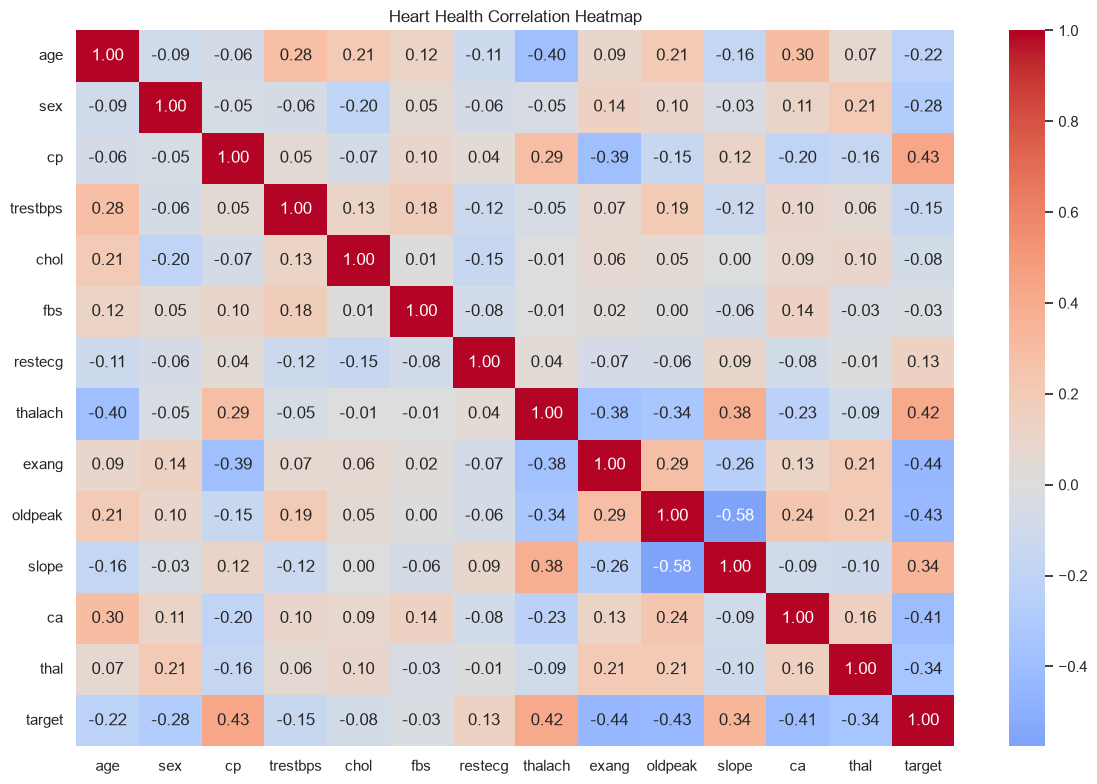

In [35]:
#Advanced Level Questions

#1.Correlation heatmap

correlation_matrix = data.drop(
    columns=["age_group"]
).corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Heart Health Correlation Heatmap")

plt.tight_layout()
plt.show()

In [36]:
#2. Find strongest correlation with target
target_correlation = (
    data.drop(columns=["age_group"])
    .corr()["target"]
    .sort_values(
        ascending=False
    )
)

print("\nCorrelation with heart disease:")
print(target_correlation)


Correlation with heart disease:
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [40]:
#3. Logistic Regression


X = data.drop(
    columns=["target", "age_group"]
)

y = data["target"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic",
        LogisticRegression(
            max_iter=2000
        )
    )
])



model.fit(
    X_train,
    y_train
)



y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]

accuracy = accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\nLogistic Regression Results")

print("Accuracy:")
print(round(accuracy, 4))

print("\nROC-AUC:")
print(round(roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Logistic Regression Results
Accuracy:
0.8033

ROC-AUC:
0.8712

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



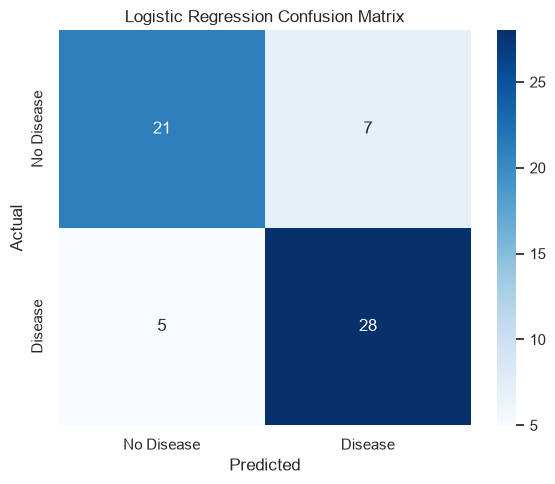

In [41]:
#4. Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Disease",
        "Disease"
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


Logistic Regression Coefficients:
     Feature  Coefficient  Absolute_Coefficient
2         cp     0.978893              0.978893
1        sex    -0.876002              0.876002
7    thalach     0.818189              0.818189
11        ca    -0.740095              0.740095
12      thal    -0.521572              0.521572
8      exang    -0.499109              0.499109
9    oldpeak    -0.400050              0.400050
3   trestbps    -0.358746              0.358746
10     slope     0.309090              0.309090
4       chol    -0.279967              0.279967
6    restecg     0.224004              0.224004
5        fbs    -0.112431              0.112431
0        age     0.087868              0.087868


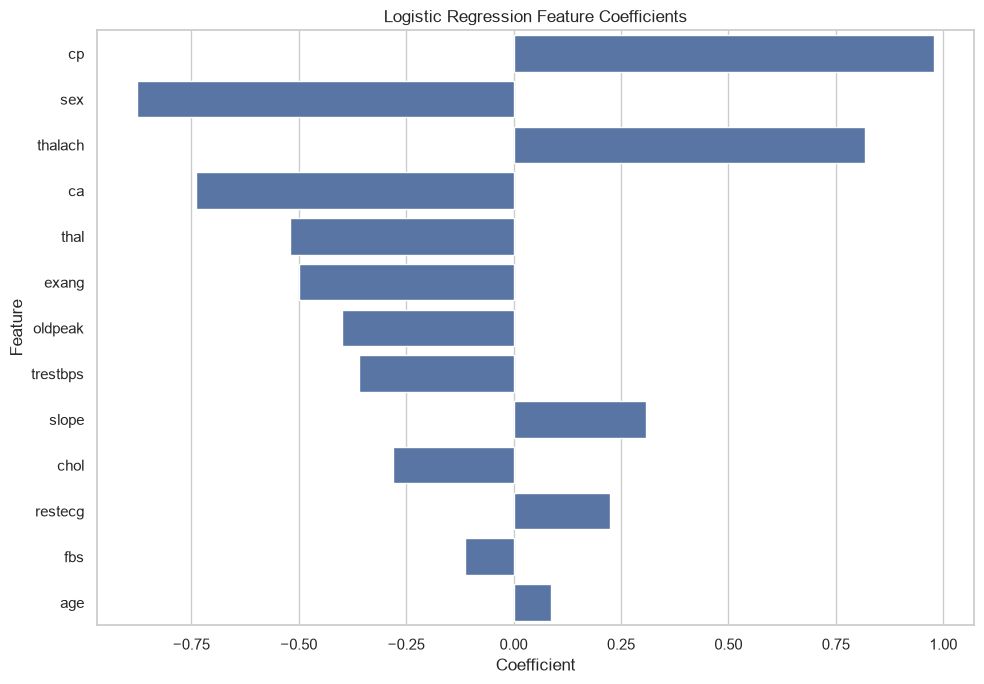

In [42]:
#5.Feature importance

logistic_model = model.named_steps["logistic"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\nLogistic Regression Coefficients:")
print(coefficients)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Logistic Regression Feature Coefficients"
)

plt.tight_layout()
plt.show()

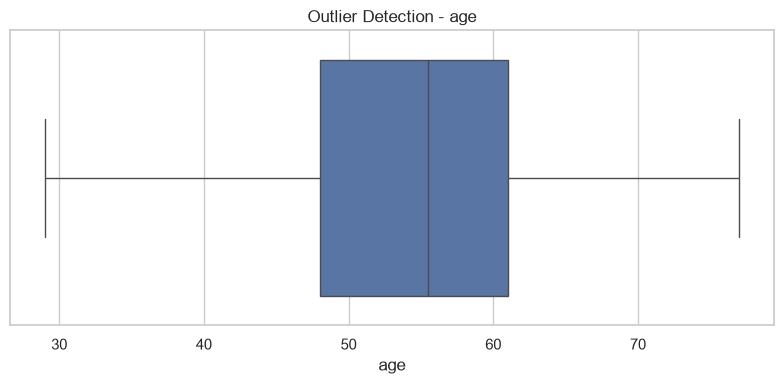

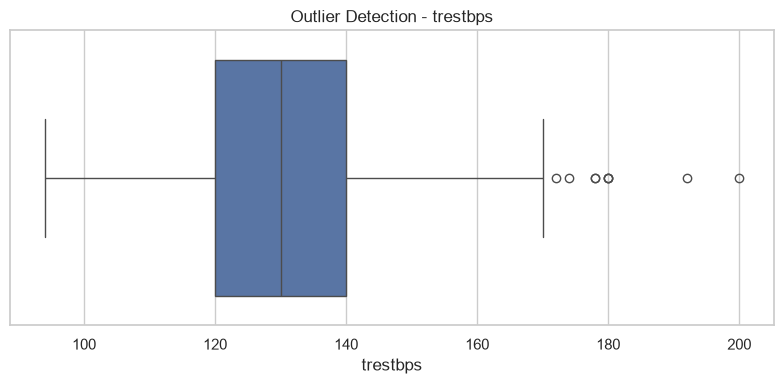

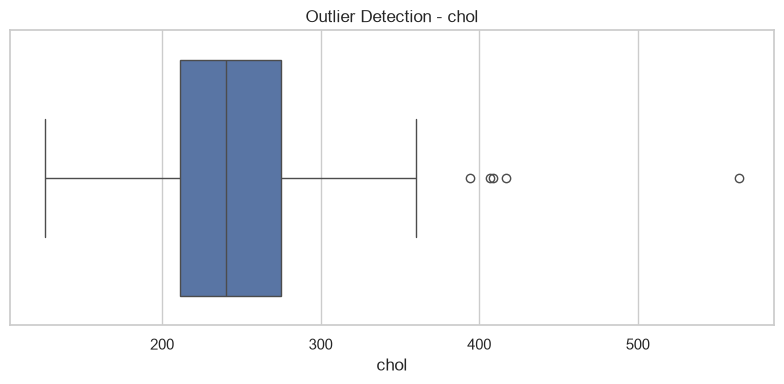

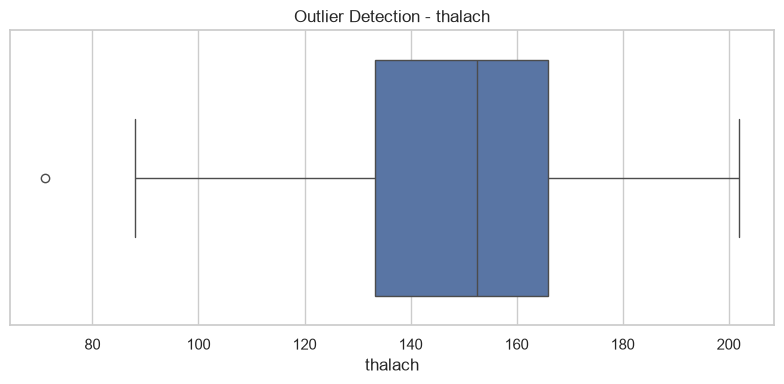

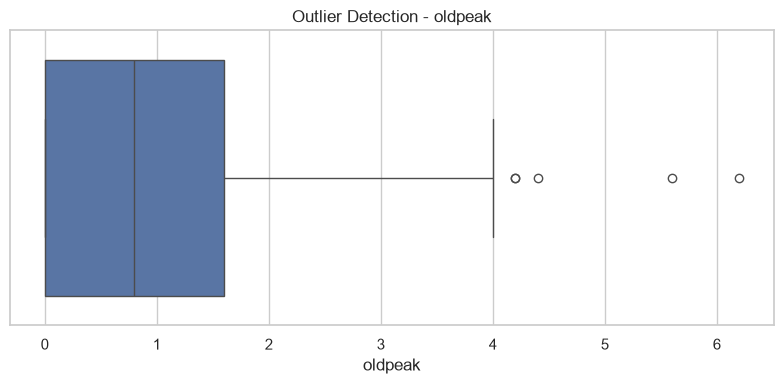

In [43]:
#6. Outlier detection

columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=data[column]
    )

    plt.title(
        f"Outlier Detection - {column}"
    )

    plt.tight_layout()
    plt.show()

In [44]:
#7. Normalization

scaler = StandardScaler()

normalized_data = data.copy()

normalized_data[columns] = scaler.fit_transform(
    normalized_data[columns]
)

print("\nNormalized data:")
print(
    normalized_data[columns].head()
)


Normalized data:
        age  trestbps      chol   thalach   oldpeak
0 -0.267966 -0.376556 -0.667728  0.806035 -0.037124
1 -0.157260  0.478910 -0.841918  0.237495  1.773958
2  1.724733  0.764066 -1.403197 -1.074521  1.342748
3  0.728383  0.935159 -0.841918  0.499898 -0.899544
4  0.839089  0.364848  0.919336 -1.905464  0.739054
